<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# ALGORITMOS EVOLUTIVOS I

## TRABAJO PRÁCTICO FINAL


#### ALUMNO: MAURO FABIAN BARQUINERO


#### Imports

In [9]:
import random
import matplotlib.pyplot as plt
random.seed(2025)

#### Catálogo

In [10]:

# Catálogo (nombre, peso_kg, utilidad)
catalog = [
    ("Botiquín primeros auxilios", 0.50, 8.5),
    ("Agua (1.5 L)",               1.50, 8.0),
    ("Comida",                     0.60, 7.5),
    ("Linterna frontal",           0.20, 7.0),
    ("Navaja multiusos",           0.25, 6.5),
    ("Encendedor / fósforos",      0.20, 4.0),
    ("Silbato",                    0.20, 3.5),
    ("Navegación (mapa+brújula/GPS)", 0.25, 7.0),
    ("Teléfono móvil",             0.20, 6.0),
    ("Batería externa",            0.30, 6.0),
    ("Gafas de sol",               0.10, 5.5),
    ("Protector solar",            0.10, 5.0),
    ("Sombrero / gorra",           0.10, 5.0),
    ("Capa térmica (1ª piel)",     0.40, 8.0),
    ("Campera impermeable",        0.90, 9.0),
    ("Guantes térmicos",           0.30, 6.5),
    ("Gorro térmico",              0.20, 5.5),
    ("Arnés",                      0.50, 7.0),
    ("Casco",                      0.40, 8.0),
    ("Piolet",                     0.70, 7.0),
    ("Crampones",                  0.90, 7.5),
    ("Cuerda (30 m)",              2.00, 7.5),

    # Ropa / Abrigo extra
    ("Pantalón softshell",         0.60, 7.5),
    ("Pantalón impermeable",       0.40, 7.0),
    ("Polar (capa media)",         0.40, 7.5),
    ("Chaqueta de pluma/sintética",0.60, 8.5),
    ("Calcetines térmicos extra",  0.10, 5.0),
    ("Polainas",                   0.60, 5.5),

    # Protección/clima
    ("Barra labial SPF",           0.25, 4.5),
    ("Gafas de sol (repuesto)",    0.30, 4.0),
    ("Crema de manos/antirozaduras", 0.20, 3.5),

    # Hidratación / comida
    ("Agua extra 1.0 L",           1.00, 7.0),
    ("Termo 0.5 L",                0.60, 5.5),
    ("Snacks energéticos",         0.45, 6.5),
    ("Filtro/pastillas potabilizadoras", 0.10, 5.5),
    ("Bolsa de hidratación (vacía)",0.45, 3.5),

    # Cocina / Vivac ligero
    ("Olla/taza liviana",          0.45, 4.5),
    ("Encendedor de ferrocerio (respaldo)", 0.30, 3.5),
    ("Manta térmica de emergencia",0.30, 6.0),
    ("Saco de vivac ultraligero",  0.35, 6.0),

    # Navegación / comunicación
    ("Altímetro/barómetro",        0.30, 5.5),
    ("Baterías AA/AAA de repuesto",0.35, 5.5),
    ("Radio VHF",                  0.50, 6.5),
    ("Baliza satelital / PLB",     0.15, 8.5),
    ("Espejo de señales",          0.30, 4.0),
    ("Cinta reflectiva / luz estroboscópica", 0.25, 4.5),

    # Herramientas / reparación
    ("Cinta americana (rollito)",  0.40, 5.5),
    ("Bridas (pack)",              0.30, 4.5),
    ("Kit reparación (parches/costura)", 0.40, 5.0),
    ("Cordín 5–6 mm (5 m)",        0.60, 6.0),
    ("Mosquetón HMS",              0.30, 5.5),
    ("Asegurador/descensor (ATC)", 0.30, 6.5),
    ("Cintas anillo 120 cm x2",    0.35, 6.0),
    ("Cintas exprés x4",           0.55, 6.5),

    # Terreno técnico
    ("Microspikes",                0.60, 6.5),
    ("Juego de empotradores (nuts)", 0.75, 6.5),
    ("Juego de friends pequeño",   1.20, 6.0),
    ("Tornillos de hielo x2",      0.40, 6.0),
    ("Martillo",                   0.35, 4.5),
    ("Bastones de trekking",       0.80, 5.0),
]

items = [[w, v] for (_, w, v) in catalog]
IDX = {name: i for i, (name, _, _) in enumerate(catalog)}
N = len(items)
print("Total ítems:", N)

Total ítems: 60


#### Soft constraints

In [11]:
# Capacidad máxima de la mochila en kilogramos
W = 9.2
# Coeficiente de penalización por sobrepeso en la función de fitness.
LAMBDA_W = 150.0

# Bonus
BONUS = {
    "Agua (1.5 L)": 8.0,
    "Comida": 6.0,
    "Botiquín primeros auxilios": 5.0,
    "Navegación (mapa+brújula/GPS)": 4.0,
    "Linterna frontal": 3.0,
    "Teléfono móvil": 2.0,
    "Batería externa": 2.0,
    "Navaja multiusos": 2.0,
    "Cuerda (30 m)": 12.0,
    "Arnés": 4.0,
    "Casco": 5.0,
    "Capa térmica (1ª piel)" : 4.0,
    "Campera impermeable" : 6.0,
}
# Penalidades
PENAL_MISS = {
    "Agua (1.5 L)": 30.0,
    "Comida": 18.0,
    "Botiquín primeros auxilios": 12.0,
    "Navegación (mapa+brújula/GPS)": 8.0,
    "Linterna frontal": 6.0,
    "Teléfono móvil": 4.0,
    "Batería externa": 4.0,
    "Navaja multiusos": 4.0,
    "Cuerda (30 m)": 35.0,
    "Arnés": 8.0,
    "Casco": 8.0,
    "Capa térmica (1ª piel)" : 10.0,
    "Campera impermeable" : 14.0,
}

# Dependencias mínimas para coherencia
DEPENDENCIES = [
    ("Cuerda (30 m)", ["Arnés", "Casco"], 12.0),
    ("Asegurador/descensor (ATC)", ["Cuerda (30 m)"], 14.0),
    ("Cintas exprés x4", ["Cuerda (30 m)"], 8.0),
]

#### Fitness y GA

=== Mejor solución (simple, W=9.2) ===
W=9.2 kg | Peso total: 9.15 | Utilidad base: 138.5 | Fitness: 201.5
Cantidad de ítems: 20
Ítems seleccionados:
 - 00 | Botiquín primeros auxilios | 0.5 kg | util 8.5
 - 01 | Agua (1.5 L) | 1.5 kg | util 8.0
 - 02 | Comida | 0.6 kg | util 7.5
 - 03 | Linterna frontal | 0.2 kg | util 7.0
 - 04 | Navaja multiusos | 0.25 kg | util 6.5
 - 07 | Navegación (mapa+brújula/GPS) | 0.25 kg | util 7.0
 - 08 | Teléfono móvil | 0.2 kg | util 6.0
 - 09 | Batería externa | 0.3 kg | util 6.0
 - 10 | Gafas de sol | 0.1 kg | util 5.5
 - 11 | Protector solar | 0.1 kg | util 5.0
 - 12 | Sombrero / gorra | 0.1 kg | util 5.0
 - 13 | Capa térmica (1ª piel) | 0.4 kg | util 8.0
 - 14 | Campera impermeable | 0.9 kg | util 9.0
 - 15 | Guantes térmicos | 0.3 kg | util 6.5
 - 17 | Arnés | 0.5 kg | util 7.0
 - 18 | Casco | 0.4 kg | util 8.0
 - 21 | Cuerda (30 m) | 2.0 kg | util 7.5
 - 34 | Filtro/pastillas potabilizadoras | 0.1 kg | util 5.5
 - 43 | Baliza satelital / PLB | 0.15

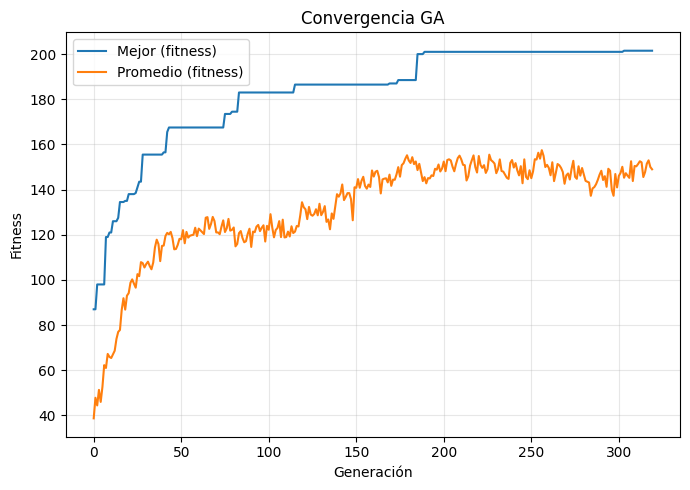

In [12]:
def chrom_weight_value(ch):
    """
    Calcula el peso y la utilidad base de un cromosoma.

    Un cromosoma `ch` es una lista de bits (0/1) de longitud N, donde 1 indica
    que el ítem i-ésimo del catálogo está seleccionado.
    """
    w=v=0.0
    for i,b in enumerate(ch):
        if b:
            w += items[i][0]; v += items[i][1]
    return w,v

def fitness(ch):
    """
    Función de aptitud (fitness) con restricciones suaves.

    La aptitud parte de la utilidad base y aplica:
      - BONOS por ítems deseables presentes (BONUS).
      - PENALES por críticos faltantes (PENAL_MISS).
      - PENALES por violar dependencias (DEPENDENCIES).
      - Penalización por sobrepeso proporcional a (w - W) con coeficiente LAMBDA_W.
        Valor de fitness (más alto es mejor).
    """
    w,v = chrom_weight_value(ch)
    f = v
    for name,b in BONUS.items():
        idx = IDX.get(name); 
        if idx is not None and ch[idx]==1: f += b
    for name,p in PENAL_MISS.items():
        idx = IDX.get(name); 
        if idx is not None and ch[idx]==0: f -= p
    for trig, reqs, pen in DEPENDENCIES:
        t = IDX.get(trig)
        if t is not None and ch[t]==1:
            for rn in reqs:
                r = IDX.get(rn)
                if r is not None and ch[r]==0: f -= pen
    if w > W: f -= LAMBDA_W * (w - W)
    return f

POP = 140
GEN = 320
PMUT = 0.25
ELITISM  = 1

def rand_chrom():
    """
    Genera un cromosoma aleatorio (lista de 0/1) de longitud N.
    """
    return [random.randint(0,1) for _ in range(N)]

def gen_pop(n): 
    """
    Crea una población inicial de tamaño `n` con cromosomas aleatorios.
        Lista de cromosomas.
    """
    return [rand_chrom() for _ in range(n)]

def select_parents(pop):
    """
    Selección por ruleta con salvaguardas.

    Se calcula el fitness de cada individuo; si la suma de fitness positivos es
    cero o negativa, se seleccionan padres al azar para evitar bloqueos.
    """
    vals = [max(fitness(c), -1e9) for c in pop]
    s = sum(max(v,0.0) for v in vals)
    if s<=0: return random.choice(pop), random.choice(pop)
    wts = [max(v,0.0)/s for v in vals]
    return (random.choices(pop, weights=wts, k=1)[0],
            random.choices(pop, weights=wts, k=1)[0])

def crossover(p1,p2):
    """
    Cruce de 1 punto entre dos padres.
    """
    cx = random.randint(1, N-1)
    return p1[:cx]+p2[cx:], p2[:cx]+p1[cx:]

def mutate(ch):
    """
    Mutación de un bit (flip 0↔1) en una posición aleatoria.
    """
    i = random.randint(0, N-1)
    ch[i] = 1 - ch[i]
    return ch

def best_of(pop): 
    """
    Devuelve el mejor individuo de la población según `fitness`.
    """   
    return max(pop, key=lambda c: fitness(c))

# Evolución
pop = gen_pop(POP)
best_hist=[]; mean_hist=[]
for _ in range(GEN):
    elites = sorted(pop, key=lambda c: fitness(c), reverse=True)[:ELITISM] if ELITISM>0 else []
    off=[]
    while len(off) < POP - len(elites):
        p1,p2 = select_parents(pop)
        c1,c2 = crossover(p1,p2)
        if random.random()<PMUT: c1 = mutate(c1)
        if random.random()<PMUT: c2 = mutate(c2)
        off.extend([c1,c2])
    pop = elites + off[:POP-len(elites)]
    vals = [fitness(c) for c in pop]
    best_hist.append(max(vals)); mean_hist.append(sum(vals)/len(vals))

best = best_of(pop)
bw, bv = chrom_weight_value(best)
print("=== Mejor solución (simple, W=9.2) ===")
print(f"W={W} kg | Peso total: {bw:.2f} | Utilidad base: {bv:.1f} | Fitness: {fitness(best):.1f}")
print("Cantidad de ítems:", sum(best))
print("Ítems seleccionados:")
for i,b in enumerate(best):
    if b==1:
        print(f" - {i:02d} | {catalog[i][0]} | {items[i][0]} kg | util {items[i][1]}")

plt.figure(figsize=(7,5))
plt.plot(best_hist, label="Mejor (fitness)")
plt.plot(mean_hist, label="Promedio (fitness)")
plt.xlabel("Generación"); plt.ylabel("Fitness")
plt.title("Convergencia GA")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("convergencia_soft_simple.png", dpi=150)
print("\nGráfico guardado: convergencia_soft_simple.png")
